# Thevenin's theorem

A circuit is variable might be variable while other elements are fixed. A household outlet terminal may be connected to different
appliances constituting a variable load. To avoid reanalysing each time a variable element is changed, Thevenin’s theorem provides a technique by which the fixed part of the circuit is replaced by an equivalent circuit.

## Using Thevenin equivalents in fault analysis

Thevenin equivalents are widely used in power system fault analysis because they simplify a complex network into a single voltage source and impedance seen from the fault location.

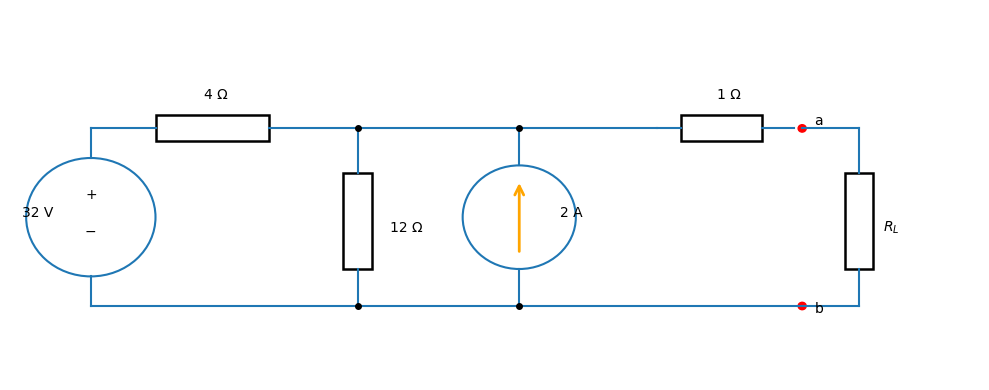

In [35]:
# TEST CELL
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch


def draw_resistor_iec(ax, x1, y1, x2, y2,
                      width=0.35,
                      color="black",
                      lw=1.8):
    """Draw IEC/European rectangular resistor."""

    # Vertical resistor
    if abs(x2 - x1) < 1e-6:
        height = abs(y2 - y1)
        y_bottom = min(y1, y2)

        rect = Rectangle(
            (x1 - width / 2, y_bottom),
            width,
            height,
            fill=False,
            edgecolor=color,
            linewidth=lw,
        )
        ax.add_patch(rect)

    # Horizontal resistor
    elif abs(y2 - y1) < 1e-6:
        length = abs(x2 - x1)
        x_left = min(x1, x2)

        rect = Rectangle(
            (x_left, y1 - width / 2),
            length,
            width,
            fill=False,
            edgecolor=color,
            linewidth=lw,
        )
        ax.add_patch(rect)


fig, ax = plt.subplots(figsize=(10, 4))

ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

wire = "#1f77b4"

# Bottom bus
ax.plot([1, 10.5], [1, 1], color=wire, lw=1.5)

# Voltage source (32 V)
ax.plot([1, 1], [1, 1.4], color=wire, lw=1.5)
ax.plot([1, 1], [3.0, 3.4], color=wire, lw=1.5)

ax.add_patch(
    Circle((1, 2.2), 0.8,
           fill=False,
           edgecolor=wire,
           linewidth=1.5)
)

ax.text(1, 2.45, "+", ha="center")
ax.text(1, 1.95, "−", ha="center")
ax.text(0.15, 2.2, "32 V")

# Top wire and 4-ohm resistor
ax.plot([1, 1.8], [3.4, 3.4], color=wire, lw=1.5)

draw_resistor_iec(ax, 1.8, 3.4, 3.2, 3.4)
ax.text(2.4, 3.8, "4 Ω")

ax.plot([3.2, 8.0], [3.4, 3.4], color=wire, lw=1.5)

# 12-ohm branch
xr = 4.3
ax.plot([xr, xr], [3.4, 2.8], color=wire, lw=1.5)
draw_resistor_iec(ax, xr, 2.8, xr, 1.5)
ax.text(xr + 0.4, 2.0, "12 Ω")
ax.plot([xr, xr], [1, 1.5], color=wire, lw=1.5)

# 2-A current source branch
xi = 6.3
ax.plot([xi, xi], [3.4, 2.9], color=wire, lw=1.5)
ax.plot([xi, xi], [1.5, 1], color=wire, lw=1.5)

ax.add_patch(
    Circle((xi, 2.2), 0.7,
           fill=False,
           edgecolor=wire,
           linewidth=1.5)
)

ax.add_patch(
    FancyArrowPatch(
        (xi, 1.7),
        (xi, 2.7),
        arrowstyle="->",
        mutation_scale=16,
        linewidth=2,
        color="orange",
    )
)

ax.text(xi + 0.5, 2.2, "2 A")

# Node dots
for x in [xr, xi]:
    ax.plot(x, 3.4, "ko", ms=4)
    ax.plot(x, 1.0, "ko", ms=4)

# 1-ohm resistor
ax.plot([8.0, 8.3], [3.4, 3.4], color=wire, lw=1.5)

draw_resistor_iec(ax, 8.3, 3.4, 9.3, 3.4)
ax.text(8.75, 3.8, "1 Ω")

# Terminal a
ax.plot([9.3, 9.7], [3.4, 3.4], color=wire, lw=1.5)
ax.add_patch(Circle((9.8, 3.4), 0.05, color="red"))
ax.text(9.95, 3.45, "a")
ax.plot([10.5, 10.5], [3.4, 2.8], color=wire, lw=1.5)

# Terminal b
ax.add_patch(Circle((9.8, 1.0), 0.05, color="red"))
ax.text(9.95, 0.9, "b")
ax.plot([10.5, 10.5], [1.5, 1], color=wire, lw=1.5)

# Load resistor RL
ax.plot([9.8, 10.5], [3.4, 3.4], color=wire, lw=1.5)
draw_resistor_iec(ax, 10.5, 2.8, 10.5, 1.5)
ax.text(10.8, 2.0, r"$R_L$")

#ax.set_title("IEC / European Style Circuit Diagram")

plt.tight_layout()
plt.show()


# Thevenin Equivalent Using Mesh Analysis

```text
Circuit:
- 32 V independent voltage source
- 4 Ω resistor
- 12 Ω resistor
- 2 A current source
- 1 Ω resistor to terminal a
- Find Thevenin equivalent at terminals a-b
```

## Step 1: Find Thevenin Voltage (Vth)

Remove the load RL.

Since RL is removed, no current flows through the 1 Ω resistor, therefore:


$$ Va = V_{TH} $$




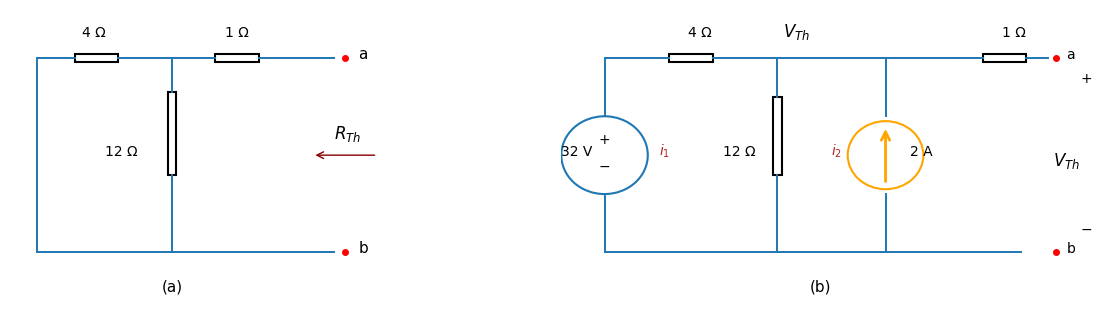

In [39]:
# TEST CELL
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch

# -------------------------------------------------
# Helper functions
# -------------------------------------------------

def resistor_h(ax, x, y, length=0.8, height=0.15):
    ax.add_patch(
        Rectangle((x, y - height/2), length, height,
                  fill=False, linewidth=1.5, edgecolor='black')
    )


def resistor_v(ax, x, y, width=0.15, height=0.8):
    ax.add_patch(
        Rectangle((x - width/2, y), width, height,
                  fill=False, linewidth=1.5, edgecolor='black')
    )

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3), constrained_layout=True)

for ax in [ax1, ax2]:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis('off')

wire = '#1f77b4'

# FIGURE (a)
ax1.plot([0.5,0.5],[1,5],color=wire,lw=1.4)
ax1.plot([0.5,1.2],[5,5],color=wire,lw=1.4)
resistor_h(ax1,1.2,5)
ax1.text(1.55,5.45,'4 Ω',ha='center')
ax1.plot([2.0,3.8],[5,5],color=wire,lw=1.4)
resistor_h(ax1,3.8,5)
ax1.text(4.2,5.45,'1 Ω',ha='center')
ax1.plot([4.6,6.0],[5,5],color=wire,lw=1.4)
ax1.plot(6.2,5,'ro',ms=4)
ax1.text(6.45,5,'a',fontsize=11)
ax1.plot([3.0,3.0],[5,4.3],color=wire,lw=1.4)
resistor_v(ax1,3.0,2.6,height=1.7)
ax1.plot([3.0,3.0],[2.6,1.0],color=wire,lw=1.4)
ax1.text(1.75,3.0,'12 Ω')
ax1.plot([0.5,6.0],[1,1],color=wire,lw=1.4)
ax1.plot(6.2,1,'ro',ms=4)
ax1.text(6.45,1,'b',fontsize=11)
ax1.add_patch(FancyArrowPatch((6.8,3.0),(5.6,3.0),arrowstyle='->',mutation_scale=12,color='darkred'))
ax1.text(6.0,3.35,r'$R_{Th}$',fontsize=12)
ax1.text(3.0,0.2,'(a)',ha='center',fontsize=11)

# FIGURE (b)
ax2.plot([0.8,0.8],[1,2.2],color=wire,lw=1.4)
ax2.plot([0.8,0.8],[3.8,5],color=wire,lw=1.4)
ax2.add_patch(Circle((0.8,3),0.8,fill=False,linewidth=1.5,edgecolor=wire))
ax2.text(0.8,3.25,'+',ha='center')
ax2.text(0.8,2.7,'−',ha='center')
ax2.plot([0.8,2.0],[5,5],color=wire,lw=1.4)
resistor_h(ax2,2.0,5)
ax2.text(2.35,5.45,'4 Ω')
ax2.plot([2.8,7.3],[5,5],color=wire,lw=1.4)
ax2.text(4.1,5.45,r'$V_{Th}$',fontsize=12)
xR = 4.0
ax2.plot([xR,xR],[5,4.2],color=wire,lw=1.4)
resistor_v(ax2,xR,2.6,height=1.6)
ax2.plot([xR,xR],[2.6,1],color=wire,lw=1.4)
ax2.text(3.0,3.0,'12 Ω')
xI = 6.0
ax2.plot([xI,xI],[5,3.8],color=wire,lw=1.4)
ax2.plot([xI,xI],[2.2,1],color=wire,lw=1.4)
ax2.add_patch(Circle((xI,3.0),0.7,fill=False,edgecolor='orange',linewidth=1.5))
ax2.add_patch(FancyArrowPatch((xI,2.4),(xI,3.6),arrowstyle='->',mutation_scale=15,color='orange',linewidth=2))
ax2.text(6.45,3.0,'2 A')
ax2.plot([0.8,8.5],[1,1],color=wire,lw=1.4)
ax2.plot([7.3,7.8],[5,5],color=wire,lw=1.4)
resistor_h(ax2,7.8,5)
ax2.text(8.15,5.45,'1 Ω')
ax2.plot([8.6,9.0],[5,5],color=wire,lw=1.4)
ax2.plot(9.15,5,'ro',ms=4)
ax2.text(9.35,5,'a')
ax2.plot(9.15,1,'ro',ms=4)
ax2.text(9.35,1,'b')
ax2.text(9.6,4.5,'+')
ax2.text(9.6,1.4,'−')
ax2.text(9.1,2.8,r'$V_{Th}$',fontsize=12)
ax2.text(1.8,3.0,r'$i_1$',color='firebrick')
ax2.text(5.0,3.0,r'$i_2$',color='firebrick')
ax2.text(0.0,3.0,'32 V')
ax2.text(4.8,0.2,'(b)',ha='center',fontsize=11)

plt.show()


### Define Mesh Currents


$i_1$ = Left mesh current (clockwise)

$i_2$ = Right mesh current (clockwise)


The 2 A source fixes the right mesh current:


$$i_2 = -2 A$$

### Mesh 1 Equation (KVL)

Applying KVL around Mesh 1:

$$
-32 + 4i_1 + 12(i_1 - i_2) = 0
$$

The current source fixes the second mesh current:

$$
i_2 = -2\ \text{A}
$$

Substituting into the KVL equation:

$$
-32 + 4i_1 + 12\bigl(i_1 - (-2)\bigr) = 0
$$

$$
-32 + 4i_1 + 12(i_1 + 2) = 0
$$

Expanding:

$$
-32 + 4i_1 + 12i_1 + 24 = 0
$$

Combining like terms:

$$
16i_1 - 8 = 0
$$

$$
16i_1 = 8
$$

Solving for $i_1$:

$$
i_1 = \frac{8}{16}
$$

$$
i_1 = 0.5\ \text{A}
$$


### Calculate Open-Circuit Voltage

```text
Voc = 12(I1 - I2)
```

Substitute values:

```text
Voc = 12(0.5 - (-2))
Voc = 12(2.5)
Voc = 30 V
```

Therefore:

```text
Vth = Va = 30 V
```

## Step 2: Find Thevenin Resistance (Rth)

Deactivate all independent sources.

```text
32 V source -> Short circuit
2 A source  -> Open circuit
```

Remaining network:

```text
4 Ω || 12 Ω
```

Parallel equivalent:

```text
Rp = (4 × 12)/(4 + 12)
Rp = 48/16
Rp = 3 Ω
```

Add the series 1 Ω resistor:

```text
Rth = 1 + 3
Rth = 4 Ω
```

## Final Answer

```text
Vth = 30 V
Rth = 4 Ω
```

### Thevenin Equivalent Circuit

```text
      +30 V
 a o----( )----/\/\/----o b
               4 Ω
```